# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [ ]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 51.4 MB/s eta 0:00:00


In [ ]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [ ]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialisation des outils NLTK
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:  # (-> str) est Optionel
    """Nettoie le texte : passage en minuscules, tokenisation, retrait de la ponctuation/stopwords et lemmatisation."""
    # 1. Passage en minuscules pour l'uniformité
    text = text.lower()

    # 2. Tokenisation : transformation de la phrase en liste de mots
    tokens = word_tokenize(text)

    # 3. Filtrage : on retire la ponctuation et les mots vides (stopwords)
    # On ne garde que les caractères alphanumériques qui ne sont pas dans stop_words
    cleaned_tokens = [
        t for t in tokens
        if t not in string.punctuation and t not in stop_words and t.isalnum()
    ]

    # 4. Lemmatisation : réduction des mots à leur racine (ex: 'dishes' -> 'dish')
    lemmatized_tokens = [lemmatizer.lemmatize(t) for t in cleaned_tokens]

    # 5. Reconstruction de la chaîne de caractères finale
    return " ".join(lemmatized_tokens)

# Test de la fonction sur le premier avis pour vérification
example_raw = raw_reviews[0]
example_cleaned = preprocess_text(example_raw)
print(f"Exemple brut : {example_raw}")
print(f"Exemple nettoyé : {example_cleaned}")

Exemple brut : At McDonald's the food was ok and the service was bad.
Exemple nettoyé : mcdonald food ok service bad


### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [ ]:
# On applique la fonction de nettoyage à chaque avis de la liste raw_reviews
cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

# Affichage pédagogique pour comparer le texte original et le texte traité
for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"ORIGINAL : {raw}")
    print(f"NETTOYÉ  : {cleaned}\n")

ORIGINAL : At McDonald's the food was ok and the service was bad.
NETTOYÉ  : mcdonald food ok service bad

ORIGINAL : I would not recommend this Japanese restaurant to anyone.
NETTOYÉ  : would recommend japanese restaurant anyone

ORIGINAL : I loved this restaurant when I traveled to Thailand last summer.
NETTOYÉ  : loved restaurant traveled thailand last summer

ORIGINAL : The menu of Loving has a wide variety of options.
NETTOYÉ  : menu loving wide variety option

ORIGINAL : The staff was friendly and helpful at Google's employees restaurant.
NETTOYÉ  : staff friendly helpful google employee restaurant

ORIGINAL : The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
NETTOYÉ  : ambiance bella italia amazing pasta dish delicious

ORIGINAL : I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
NETTOYÉ  : terrible experience pizza hut pizza burnt service slow

ORIGINAL : The sushi at Sushi Express is always fresh and flavorful.


### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [ ]:
def perform_ner(text: str):
    """Retourne les paires (entité, label) trouvées par le modèle spaCy."""
    # 1. Analyse du texte par le pipeline spaCy (chargé dans la variable 'nlp')
    doc = nlp(text)

    # 2. Extraction des entités (ent.text) et de leurs types (ent.label_)
    # labels possibles : GPE (Lieux), ORG (Organisations), DATE, etc.
    entities = [(ent.text, ent.label_) for ent in doc.ents]

    return entities

# Petit test rapide sur une phrase contenant des entités
print(f"Entités trouvées dans le premier avis : {perform_ner(raw_reviews[0])}")

Entités trouvées dans le premier avis : [('McDonald', 'ORG')]


### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [ ]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Retourne les étiquettes POS (Part-of-Speech) pour un texte donné."""
    # 1. Tokenisation du texte en mots individuels
    tokens = word_tokenize(text)

    # 2. Application du tagger NLTK qui assigne un code (ex: NN pour nom, JJ pour adjectif)
    pos_tags = pos_tag(tokens)

    return pos_tags

# Petit test sur le premier avis
print(f"Étiquettes POS du premier avis :\n{perform_pos_tagging(raw_reviews[0])}")

Étiquettes POS du premier avis :
[('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]


### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [ ]:
sample_indices = [0, 1] # On prend les deux premiers exemples

for i in sample_indices:
    raw = raw_reviews[i]
    cleaned = cleaned_reviews[i]

    print(f"--- ANALYSE DE L'AVIS {i+1} ---")

    # Comparaison NER (Entités Nommées)
    print(f"NER (Brut)    : {perform_ner(raw)}")
    print(f"NER (Nettoyé) : {perform_ner(cleaned)}")

    # Comparaison POS (Grammaire)
    # On limite l'affichage aux 5 premiers tags pour plus de lisibilité
    print(f"POS (Brut)    : {perform_pos_tagging(raw)[:5]}...")
    print(f"POS (Nettoyé) : {perform_pos_tagging(cleaned)[:5]}...")
    print("\n")

--- ANALYSE DE L'AVIS 1 ---
NER (Brut)    : [('McDonald', 'ORG')]
NER (Nettoyé) : [('mcdonald food ok service', 'ORG')]
POS (Brut)    : [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN')]...
POS (Nettoyé) : [('mcdonald', 'NNS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')]...


--- ANALYSE DE L'AVIS 2 ---
NER (Brut)    : [('Japanese', 'NORP')]
NER (Nettoyé) : [('japanese', 'NORP')]
POS (Brut)    : [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT')]...
POS (Nettoyé) : [('would', 'MD'), ('recommend', 'VB'), ('japanese', 'JJ'), ('restaurant', 'NN'), ('anyone', 'NN')]...




## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [ ]:
from gensim.models import Word2Vec

# 1. Préparation des données : transformation des phrases nettoyées en listes de tokens
tokenized_reviews = [review.split() for review in cleaned_reviews]

# 2. Entraînement du modèle Word2Vec
# vector_size: dimension du vecteur (100 ici)
# window: distance max entre le mot actuel et les mots prédits
# min_count: ignore les mots qui apparaissent moins de 1 fois
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=1, sg=1)

print("Modèle Word2Vec entraîné avec succès !")

Modèle Word2Vec entraîné avec succès !


### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [ ]:
# Inspection des dimensions du modèle
vec_size = w2v_model.vector_size
vocab_size = len(w2v_model.wv)

print(f"Dimension des vecteurs : {vec_size} (Chaque mot est représenté par 100 nombres)")
print(f"Taille du vocabulaire : {vocab_size} mots uniques appris")

Dimension des vecteurs : 100 (Chaque mot est représenté par 100 nombres)
Taille du vocabulaire : 55 mots uniques appris


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

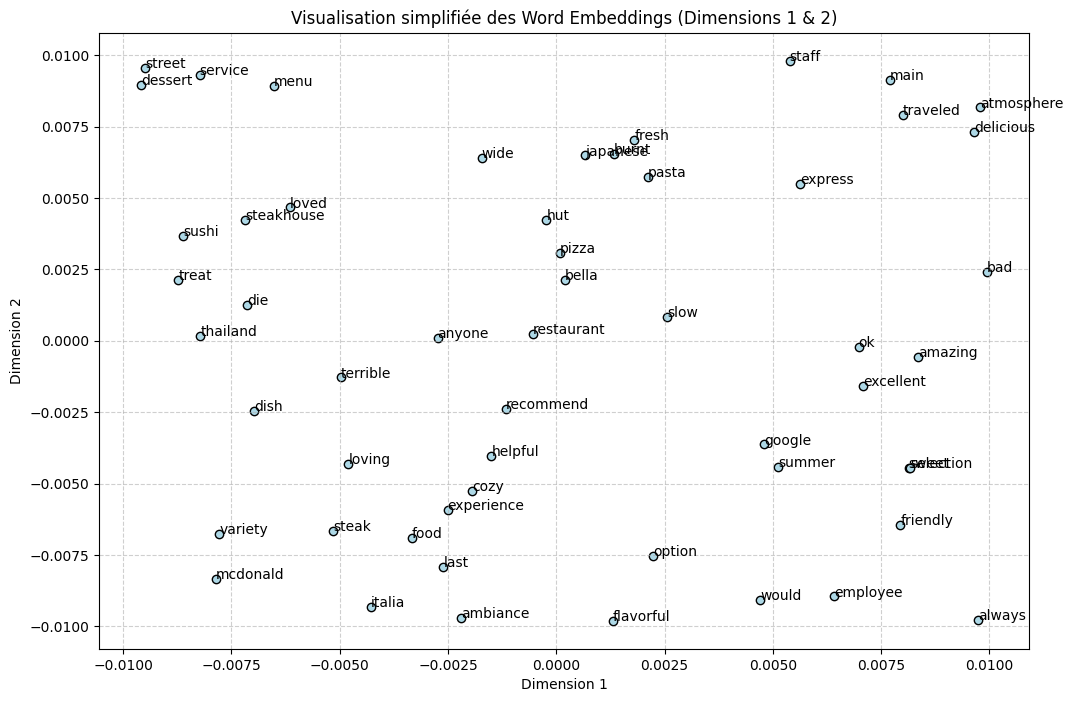

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_word_embeddings(model):
    """Affiche les vecteurs de mots dans un plan 2D (via les 2 premières dimensions)."""
    words = list(model.wv.index_to_key)
    vectors = [model.wv[word] for word in words]

    # Transformation en array numpy pour faciliter le slicing
    vectors_2d = np.array(vectors)

    plt.figure(figsize=(12, 8))
    # On utilise les deux premières colonnes (dimensions) pour le scatter plot
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], edgecolors='k', c='lightblue')

    # Ajout des étiquettes pour chaque mot
    for i, word in enumerate(words):
        plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), size=10)

    plt.title("Visualisation simplifiée des Word Embeddings (Dimensions 1 & 2)")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Appel de la fonction de visualisation
plot_word_embeddings(w2v_model)

### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.